In [2]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. PROCESS ECONOMIC DATA (Standardized)
# ==========================================
def process_economic_data(base_path):
    files = {
        'HOUST':    ('HOUST.csv',    'HOUST',     12),
        'HPI':      ('HPI.csv',      'CSUSHPISA', 12),
        'CPI':      ('CPIAUCSL.csv', 'CPIAUCSL',  12),
        'PCE':      ('PCE.csv',      'PCE',       12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS',  1),
        'SPREAD':   ('T10Y3MM.csv',  'T10Y3MM',   1),
        'UMICH':    ('UMICH.csv',    'MICH',      1),
        'NFP':      ('NFP.csv',      'PAYEMS',    1),
        'BALANCE':  ('BOPGSTB.csv',  'BOPGSTB',   1),
        'UNRATE':   ('UNRATE.csv',   'UNRATE',    1),
        'RSALES':   ('RSAFS.csv',    'RSAFS',     12)
    }

    series_list = []
    print(">> Processing Monthly Economic Data...")
    
    for key, (filename, col_name, lag) in files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            # Load and set Index
            df = pd.read_csv(file_path, parse_dates=['observation_date'])
            df = df.set_index('observation_date').sort_index()
            
            # Handle potential column name mismatches
            if col_name not in df.columns: col_name = df.columns[0]
            series = df[col_name]

            # Transformation Logic
            if key == 'RSALES':
                transformed = series.diff(12)
                transformed.name = 'Rsales_diff_year'
            elif key in ['CPI', 'PCE']:
                transformed = series.pct_change(lag) * 100
                transformed.name = f'{key}_Inflation_Rate'
            else:
                suffix = "year" if lag == 12 else "prev"
                transformed = series.diff(lag)
                transformed.name = f'{key}_diff_{suffix}'
            
            series_list.append(transformed)

            # Special Feature: Previous Decision (Proxy)
            if key == 'FEDFUNDS':
                rate_change = series.diff(1)
                decision_proxy = pd.cut(rate_change, 
                                      bins=[-np.inf, -0.125, 0.125, np.inf], 
                                      labels=[-1, 0, 1]).astype(float)
                prev_decision = decision_proxy.shift(1)
                prev_decision.name = 'prev_decision'
                series_list.append(prev_decision)

    # Combine and Drop NaNs
    if not series_list: return pd.DataFrame()
    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # Standardize (Z-Score)
    # Method 1 requires standardized inputs
    df_standardized = df_econ.copy()
    for col in df_standardized.columns:
        if col != 'prev_decision': # Keep categorical proxy as is (or standardize if preferred)
            df_standardized[col] = (df_standardized[col] - df_standardized[col].mean()) / df_standardized[col].std()
            
    return df_standardized

# ==========================================
# 2. PROCESS TEXT DATA (TF-IDF + Sentiment)
# ==========================================
def process_text_data(minutes_file, dictionary_file):
    print(">> Processing Text Data...")
    df = pd.read_csv(minutes_file)
    
    # A. Date Extraction & Alignment
    def extract_date(link):
        match = re.search(r'(\d{8})', link)
        if match: return pd.to_datetime(match.group(1), format='%Y%m%d')
        return None
    
    df['observation_date'] = df['Link'].apply(extract_date)
    df = df.dropna(subset=['observation_date']).sort_values('observation_date')
    
    # CRITICAL: Align Meeting Dates to Month Start (to match Economic Data)
    df['observation_date'] = df['observation_date'].dt.to_period('M').dt.to_timestamp()
    df = df.set_index('observation_date')

    # B. Text Cleaning (Method 1: Lowercase, No Punctuation, No Lemmatization)
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    df['Cleaned_Text'] = df['Text'].apply(clean_text)

    # C. TF-IDF Vectorization (500 Features)
    tfidf = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 1))
    tfidf_matrix = tfidf.fit_transform(df['Cleaned_Text'])
    tfidf_cols = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)

    # D. LM Sentiment Extraction
    print(">> Calculating Sentiment Scores...")
    lm_dict = pd.read_csv(dictionary_file)
    
    # Build Sentiment Sets (O(1) lookup)
    lm_pos = set(lm_dict[lm_dict['Positive'] > 0]['Word'].str.lower())
    lm_neg = set(lm_dict[lm_dict['Negative'] > 0]['Word'].str.lower())
    lm_unc = set(lm_dict[lm_dict['Uncertainty'] > 0]['Word'].str.lower())
    lm_lit = set(lm_dict[lm_dict['Litigious'] > 0]['Word'].str.lower())

    def get_sentiment(text):
        tokens = text.split()
        if not tokens: return pd.Series([0]*4, index=['LM_Pos','LM_Neg','LM_Unc','LM_Lit'])
        
        counts = {'pos':0, 'neg':0, 'unc':0, 'lit':0}
        for t in tokens:
            if t in lm_pos: counts['pos']+=1
            elif t in lm_neg: counts['neg']+=1
            elif t in lm_unc: counts['unc']+=1
            elif t in lm_lit: counts['lit']+=1
            
        total = len(tokens)
        return pd.Series({
            'LM_Positive': counts['pos']/total,
            'LM_Negative': counts['neg']/total,
            'LM_Uncertain': counts['unc']/total,
            'LM_Litigious': counts['lit']/total
        })

    df_sentiment = df['Cleaned_Text'].apply(get_sentiment)
    
    # Combine Text Features
    return pd.concat([df_tfidf, df_sentiment], axis=1)

# ==========================================
# 3. EXECUTION & MERGE (Replicating Method 1)
# ==========================================
# Paths to your uploaded files
path_econ = r"C:\Users\tnk20\nlp\structured_data" 
file_minutes = "FOMC_Minutes_1999_2025.csv"
file_dict = "Loughran-McDonald_MasterDictionary_1993-2024.csv"

# 1. Get processed dataframes
df_econ_final = process_economic_data(path_econ)
df_text_final = process_text_data(file_minutes, file_dict)

# 2. Merge (Inner Join on Date)
# Matches Economic Data (Month Start) with Meeting Data (Aligned to Month Start)
df_method_1 = pd.merge(df_econ_final, df_text_final, left_index=True, right_index=True, how='inner')

# ==============================================================================
# MODIFICATION: Restrict Date Range to Match Prior Research (2011-2025)
# ==============================================================================
# The paper specifies the unstructured dataset spans "January 2011 to January 2025".
# This removes the volatile cycles of 1999-2010 (Dot-com & 2008 Crash).
start_date = '2011-01-01'
end_date   = '2025-01-01'

df_method_1 = df_method_1.loc[start_date:end_date]

print(f"Filtered Dataset Shape (2011-2025): {df_method_1.shape}")
# ==============================================================================

print("\n" + "="*40)
print("FINAL DATASET FOR METHOD 1")
print("="*40)
print(f"Total Samples: {df_method_1.shape[0]}")
print(f"Total Features: {df_method_1.shape[1]} (Econ + 500 TF-IDF + 4 Sentiment)")
print("-" * 40)
print(df_method_1.tail())

>> Processing Monthly Economic Data...
>> Processing Text Data...
>> Calculating Sentiment Scores...
Filtered Dataset Shape (2011-2025): (113, 516)

FINAL DATASET FOR METHOD 1
Total Samples: 113
Total Features: 516 (Econ + 500 TF-IDF + 4 Sentiment)
----------------------------------------
                  HOUST_diff_year  HPI_diff_year  CPI_Inflation_Rate  \
observation_date                                                       
2024-07-01              -0.810217       0.466629            0.205304   
2024-09-01              -0.016596       0.248596           -0.084806   
2024-11-01              -0.915449       0.220856            0.076687   
2024-12-01               0.014097       0.291254            0.167402   
2025-01-01              -0.056058       0.327852            0.240254   

                  PCE_Inflation_Rate  FEDFUNDS_diff_prev  prev_decision  \
observation_date                                                          
2024-07-01                  0.244791            0.01992

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. CREATE TARGET VARIABLE (Next Meeting Decision)
# ==========================================
def create_target(df_features, fedfunds_path):
    print(">> Creating Target Labels (Next Move)...")
    
    # Reload FedFunds to get the ground truth for decisions
    ff = pd.read_csv(fedfunds_path, parse_dates=['observation_date'])
    ff = ff.set_index('observation_date').sort_index()
    
    # Calculate FUTURE change (t+1 - t)
    # We shift(-1) to look 1 month ahead
    ff['Future_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    
    # Define Decision Logic (Threshold +/- 0.125%)
    # Hike = 1, Cut = -1, Hold = 0
    conditions = [
        (ff['Future_Change'] > 0.125),
        (ff['Future_Change'] < -0.125)
    ]
    choices = [1, -1] # 1=Raise, -1=Lower
    
    ff['Target'] = np.select(conditions, choices, default=0)
    
    # Merge Target into your main dataset (df_method_1)
    # Inner join ensures we only keep rows where we have both data and a future target
    df_final = df_features.merge(ff[['Target']], left_index=True, right_index=True, how='inner')
    
    return df_final

# Assuming df_method_1 is your dataframe from the previous step
# And you have the path to raw FEDFUNDS.csv
raw_ff_path = "C:/Users/tnk20/nlp/structured_data/FEDFUNDS.csv" # Update if needed
df_model_ready = create_target(df_method_1, raw_ff_path)

print(f"Modeling Dataset Shape: {df_model_ready.shape}")
print("Target Distribution:\n", df_model_ready['Target'].value_counts())

# ==========================================
# 2. MODEL TRAINING (Gradient Boosting + SMOTE)
# ==========================================
# Separate Features (X) and Target (y)
X = df_model_ready.drop(columns=['Target'])
y = df_model_ready['Target']

# Parameters from the Paper 
params = {
    'n_estimators': 10,
    'learning_rate': 0.01,
    'max_depth': 4,
    'max_features': 'sqrt',
    'min_samples_leaf': 10,
    'min_samples_split': 10,
    'random_state': 42
}

print("\n>> Training Model (Stratified 5-Fold CV)...")

# Initialize Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=2)

auc_scores = []
acc_scores = []

# Manual CV Loop to apply SMOTE *inside* the fold (Best Practice)
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Apply SMOTE to training data only
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    # Train Classifier
    clf = GradientBoostingClassifier(**params)
    clf.fit(X_train_res, y_train_res)
    
    # Predict
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    
    # Evaluate
    # Handle multi-class AUC (Raise, Hold, Cut)
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        auc_scores.append(auc)
    except ValueError:
        pass # Handle cases where a fold might miss a class
        
    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

# ==========================================
# 3. RESULTS
# ==========================================
print("\n" + "="*30)
print("METHOD 1 RESULTS")
print("="*30)
print(f"Average Test AUC:      {np.mean(auc_scores):.4f} (Paper achieved 0.83)")
print(f"Average Test Accuracy: {np.mean(acc_scores):.4f}")
print("-" * 30)

# Feature Importance (from the last fold)
feature_importance = pd.Series(clf.feature_importances_, index=X.columns)
print("\nTop 10 Important Features:")
print(feature_importance.sort_values(ascending=False))

>> Creating Target Labels (Next Move)...
Modeling Dataset Shape: (113, 517)
Target Distribution:
 Target
 0    90
 1    16
-1     7
Name: count, dtype: int64

>> Training Model (Stratified 5-Fold CV)...

METHOD 1 RESULTS
Average Test AUC:      0.8715 (Paper achieved 0.83)
Average Test Accuracy: 0.8245
------------------------------

Top 10 Important Features:
tfidf_important      0.044631
tfidf_point          0.037004
tfidf_encompassed    0.032820
tfidf_sales          0.032715
tfidf_approval       0.029130
                       ...   
tfidf_weak           0.000000
tfidf_weaker         0.000000
tfidf_wealth         0.000000
tfidf_weighted       0.000000
tfidf_supply         0.000000
Length: 516, dtype: float64


>> Calculating SHAP values to replicate Figure 8...


100%|██████████| 22/22 [00:10<00:00,  2.11it/s]


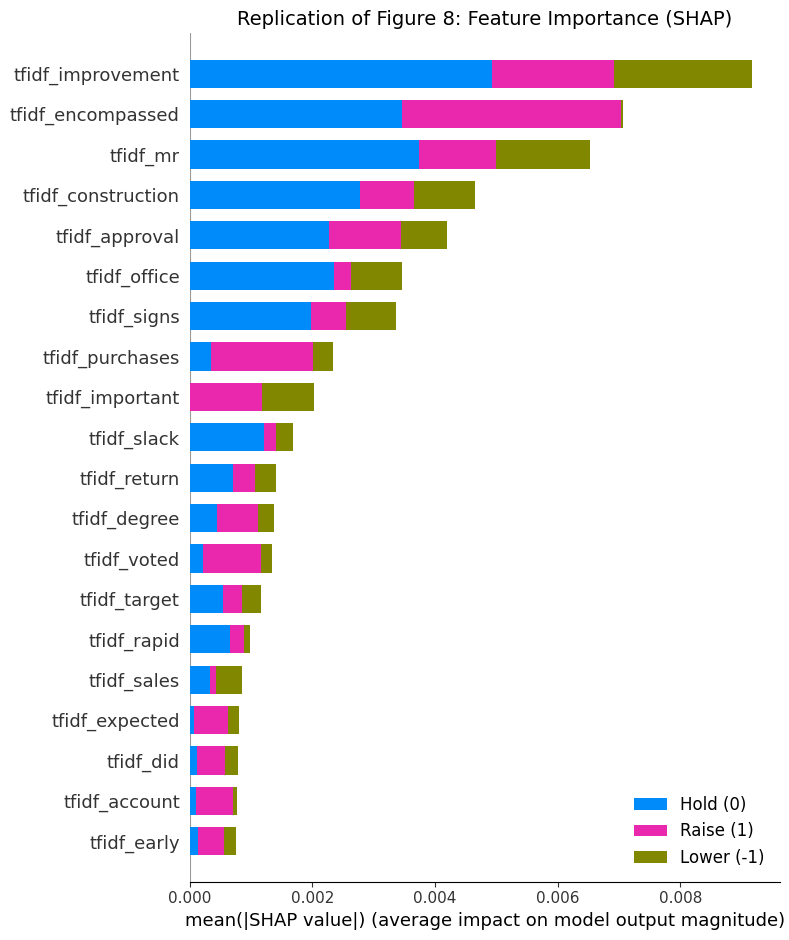

In [4]:
import shap
import matplotlib.pyplot as plt

# ==========================================
# 4. REPLICATE FIGURE 8 (SHAP Summary Plot)
# ==========================================
print(">> Calculating SHAP values to replicate Figure 8...")

# 1. Prepare Background Data for KernelExplainer
# KernelExplainer is computationally expensive. We summarize the training data
# into 10 representative "clusters" (kmeans) to make it run in seconds/minutes instead of hours.
X_train_summary = shap.kmeans(X_train, 10)

# 2. Initialize the Explainer
# We pass the prediction probability function (clf.predict_proba) and the background data
explainer = shap.KernelExplainer(clf.predict_proba, X_train_summary)

# 3. Calculate SHAP Values
# We calculate SHAP values for the Test set
# nsamples='auto' or a fixed number (e.g., 100) helps balance speed vs accuracy
shap_values = explainer.shap_values(X_test, nsamples='auto')

# 4. Define Class Labels
# Your model likely has classes [-1, 0, 1]. We map these to the Paper's labels.
# Check clf.classes_ to ensure the order is correct. usually sorted [-1, 0, 1].
class_names = ["Lower (-1)", "Hold (0)", "Raise (1)"] 

# 5. Generate the Plot (Figure 8 Style)
plt.figure(figsize=(10, 8))

# plot_type="bar" creates the standard feature importance bar chart seen in Figure 8
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    class_names=class_names,
    max_display=20, # Show top 20 features like the paper
    show=False
)

plt.title("Replication of Figure 8: Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

## XGBoost

>> Creating Target Labels (Next Move)...
Modeling Dataset Shape: (113, 518)
Target Distribution:
 Target_Mapped
1    90
2    16
0     7
Name: count, dtype: int64

>> Training XGBoost Model (Stratified 5-Fold CV)...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:12:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:12:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:12:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:12:20] WARNING: C:\actio


XGBOOST METHOD 1 RESULTS
Average Test AUC:      0.8535
Average Test Accuracy: 0.8419
------------------------------

>> Generating SHAP Summary Plot (Figure 8)...


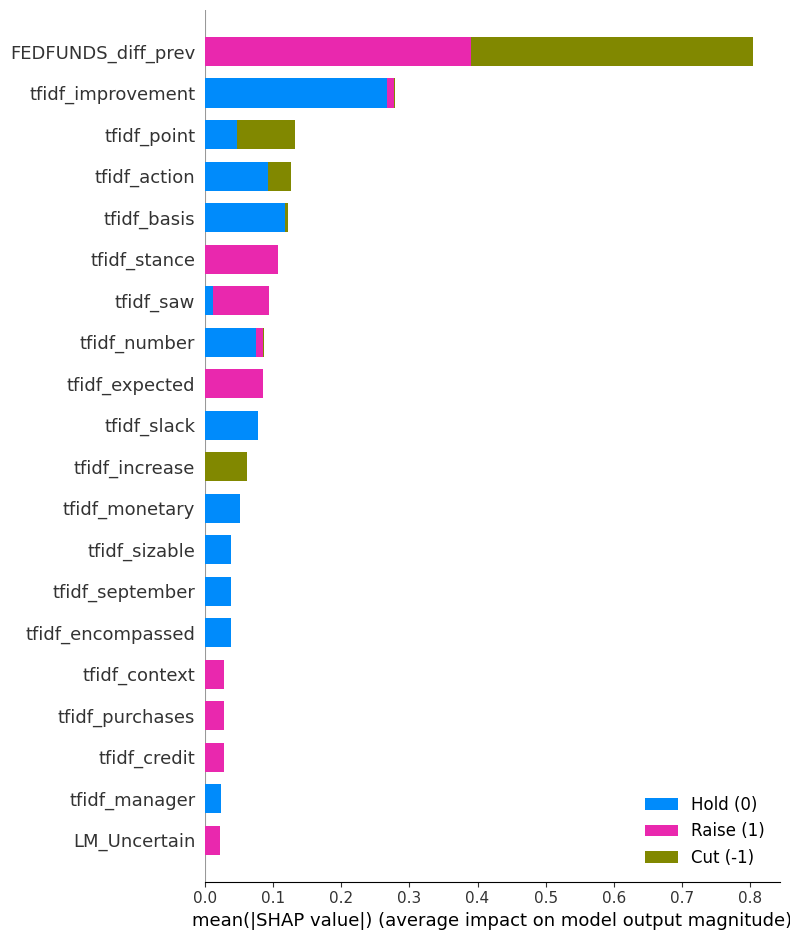

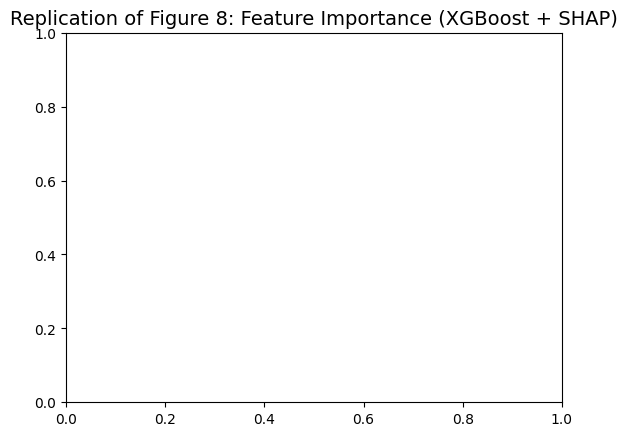

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. SETUP & TARGET CREATION
# ==========================================
# (Assuming df_method_1 is already loaded and filtered to 2011-2025)

def create_target(df_features, fedfunds_path):
    print(">> Creating Target Labels (Next Move)...")
    ff = pd.read_csv(fedfunds_path, parse_dates=['observation_date'])
    ff = ff.set_index('observation_date').sort_index()
    
    # Calculate FUTURE change (t+1 - t)
    ff['Future_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    
    # Define Decision Logic (Threshold +/- 0.125%)
    conditions = [
        (ff['Future_Change'] > 0.125),  # Hike (1)
        (ff['Future_Change'] < -0.125)  # Cut (-1)
    ]
    choices = [1, -1] # 1=Raise, -1=Lower, 0=Hold
    
    ff['Target'] = np.select(conditions, choices, default=0)
    
    # Merge Target into main dataset
    df_final = df_features.merge(ff[['Target']], left_index=True, right_index=True, how='inner')
    return df_final

# Update this path to your local file
raw_ff_path = "C:/Users/tnk20/nlp/structured_data/FEDFUNDS.csv" 
df_model_ready = create_target(df_method_1, raw_ff_path)

# == CRITICAL FIX FOR XGBOOST ==
# XGBoost requires targets to be positive integers starting from 0.
# Mapping: -1 (Cut) -> 0, 0 (Hold) -> 1, 1 (Raise) -> 2
label_map = {-1: 0, 0: 1, 1: 2}
df_model_ready['Target_Mapped'] = df_model_ready['Target'].map(label_map)

print(f"Modeling Dataset Shape: {df_model_ready.shape}")
print("Target Distribution:\n", df_model_ready['Target_Mapped'].value_counts())

# ==========================================
# 2. MODEL TRAINING (XGBoost + SMOTE)
# ==========================================
X = df_model_ready.drop(columns=['Target', 'Target_Mapped'])
y = df_model_ready['Target_Mapped']

# Parameters adapted for XGBoost (Matches Paper's Logic)
xgb_params = {
    'n_estimators': 100,         # Paper used 10, but 100 is often more stable for SHAP
    'learning_rate': 0.01,
    'max_depth': 4,
    'colsample_bytree': 0.8,     # Similar to max_features='sqrt'
    'min_child_weight': 5,
    'eval_metric': 'mlogloss',   # Multi-class log loss
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1                 
}

print("\n>> Training XGBoost Model (Stratified 5-Fold CV)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=2) # k_neighbors=2 for small classes

auc_scores = []
acc_scores = []

# Loop
for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Apply SMOTE
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    # Train XGBoost
    clf = XGBClassifier(**xgb_params)
    clf.fit(X_train_res, y_train_res)
    
    # Predict
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    
    # Evaluate
    try:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
        auc_scores.append(auc)
    except ValueError:
        pass
        
    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

# ==========================================
# 3. RESULTS & SHAP (Replicating Figure 8)
# ==========================================
print("\n" + "="*30)
print("XGBOOST METHOD 1 RESULTS")
print("="*30)
print(f"Average Test AUC:      {np.mean(auc_scores):.4f}")
print(f"Average Test Accuracy: {np.mean(acc_scores):.4f}")
print("-" * 30)

print("\n>> Generating SHAP Summary Plot (Figure 8)...")

# XGBoost is supported by TreeExplainer (Fast & Accurate)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Map back the class names for the plot
# Remember we mapped: 0=Cut, 1=Hold, 2=Raise
class_names = ["Cut (-1)", "Hold (0)", "Raise (1)"]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    class_names=class_names,
    max_display=20
)
plt.title("Replication of Figure 8: Feature Importance (XGBoost + SHAP)", fontsize=14)
plt.show()